# EXAMEN PRÁCTICO: EXPLORACIÓN DEL CONJUNTO DE DATOS (EDA)

## PREVIO: LIBRERÍAS Y FUNCIONES NECESARIAS

In [37]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import style

import seaborn as sns

import missingno as msno

%matplotlib inline

In [38]:
import warnings
warnings.filterwarnings("ignore")

style.use('ggplot') or plt.style.use('ggplot')

### FUNCIONES

In [39]:
def calculos_boxplot(columna, coef=1.5):
    """
    Calcula el Rango Intercuartílico (IQR) y los límites para valores considerados
    válidos (no extremos).
    -------------------------------
    Parametros de entrada:
    - columna: columna de un dataframe o Serie de Pandas
    - coef: valor del coeficiente para el cálculo de los límites válidos, por defecto 1.5
        Se puede ampliar si se quiere "relajar" la exigencia para dichos valores

    -------------------------------
    SALIDA:
    Devuelve una tupla (limite_inferior, limite_superior)
    y muestra por pantalla información

    """

    Q1, Q3 = columna.quantile([0.25,0.75])

    IQR = Q3 - Q1

    lim_inferior = Q1 - coef*IQR
    lim_superior = Q3 + coef*IQR

    print('Cuartiles: ', Q1, '\t', Q3)
    print('IQR: ',IQR)
    print('Limite inferior: ', lim_inferior)
    print('Limite superior: ', lim_superior)

    return lim_inferior, lim_superior


In [40]:
def categoricas_unicos(dataframe, var_cat, vc_out=True):
    """
    Muestra valores unicos y conteo de las variables categóricas.
    -------------------------------
    Parametros de entrada:
    - dataframe: DF de pandas
    - var_cat: lista de variables categóricas (cadena)
    - vc_out: booleano para mostrar o no (True/False) el resultado de "value_counts()"
        Por defecto lo muestra

    -------------------------------
    SALIDA:
    No devuelve valor. Saca por pantalla la información

    """

    for discreta in var_cat:

        print(f'Variable {discreta.upper()}:')
        print('Valores unicos: ')
        print(dataframe[discreta].unique(), end='\n'*2)

        if vc_out:
            print(dataframe[discreta].value_counts(), end='\n'*2)





In [41]:
def graf_histo_box_numericas(dataframe, var_num):
    """
    Realiza graficas histograma y boxplot de variables numéricas de un dataframe
    -------------------------------
    Parametros de entrada:
    - dataframe: DF de pandas
    - var_num: lista de variables numéricas (cadena)

    -------------------------------
    SALIDA:
    No devuelve valor. Dibuja las gráficas por pantalla

    """

    TABLEAU_CMP = ('tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', \
                   'tab:gray','tab:olive', 'tab:cyan')

    fig, axes = plt.subplots(len(var_num), 2, \
                             figsize=(20, 5 * len(var_num)), \
                             gridspec_kw={'hspace': 0.4, 'wspace': 0.1})
    ax = axes.ravel()

    # graficas distribucion y boxplot de cada atributo
    for idx, atributo in enumerate(var_num):

        # distribucion (histograma)
        sns.histplot(dataframe[atributo], bins=30, ax=ax[2 * idx], \
                     color=TABLEAU_CMP[idx % len(TABLEAU_CMP)], \
                     alpha=0.15)

        # titulo, etiquetas histograma
        ax[2 * idx].set_title(f'HISTOGRAMA {atributo}')
        ax[2 * idx].set_xlabel(f'Valores {atributo}')
        ax[2 * idx].set_ylabel("Frequencia")

        # boxplot
        sns.boxplot(x=atributo, data=dataframe, ax=ax[2 * idx + 1], color=TABLEAU_CMP[idx % len(TABLEAU_CMP)])

        # titulo, etiquetas boxplot
        ax[2 * idx + 1].set_title(f'BOXPLOT {atributo}')
        ax[2 * idx + 1].set_xlabel(f'Valores {atributo}')



## Carga y comprobación.

Para el examen usaremos el archivo **"adult_examen.csv"** (versión reducida de un dataset conocido), que se descargará de la plataforma y se subirá donde está el notebook del examen antes de que empiece el propio examen.

En este dataset se presenta información sobre las características socioeconómicas de individuos y su ingreso anual. El significado de cada uno de los campos es el siguiente:

- **ID**: campo identificativo sin otro significado
- **age**: edad
- **workclass**: tipo de trabajo
- **marital_status**: estado civil
- **sex**: género (Male/Female)
- **hours_per_week**: horas de trabajo por semana
- **capital**: ahorros
- **income**: ingreso anual (variable objetivo categórica)



\

**Como preparación a este notebook**, inspeccionen el archivo como texto plano.


Tiene cabecera, está al inicio. Le siguen los datos. El separador es la coma.

**Cargamos los datos del archivo en un Dataframe. Comprueba la carga mostrando sólo algunas filas del DataFrame (del principio, del final o aleatorio (muestra), todas son válidas, usad sólo una)**


In [42]:
ruta = 'https://raw.githubusercontent.com/SonikoKatsura/CURSO_PARO_IA/refs/heads/main/Rober_IA/Modulo2/Examen_Tema_2/adult_examen.csv'

df_adult = pd.read_csv(ruta)

df_adult.sample(n=6)

,ID,age,workclass,marital_status,sex,hours_per_week,capital,income
19198,19198,40,Private,Married-civ-spouse,Male,40,23732.933009,>50K
20864,20864,44,State-gov,Married-civ-spouse,Male,46,42337.736427,>50K
19357,19357,26,Private,Never-married,Female,45,23444.722071,<=50K
19937,19937,61,Private,Married-civ-spouse,Male,40,32265.656233,<=50K
25168,25168,21,Private,Married-civ-spouse,Female,40,NaN,<=50K
8018,8018,30,Private,Married-civ-spouse,Female,20,35703.670936,<=50K


Obtengan **información general del DataFrame** mediante el **uso de "info" y "describe"


In [43]:
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              32561 non-null  int64  
 1   age             32561 non-null  int64  
 2   workclass       30725 non-null  object 
 3   marital_status  32561 non-null  object 
 4   sex             32561 non-null  object 
 5   hours_per_week  32561 non-null  int64  
 6   capital         26150 non-null  float64
 7   income          32561 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 2.0+ MB


In [44]:
df_adult.describe()

,ID,age,hours_per_week,capital
count,32561.000000,32561.000000,32561.000000,26150.000000
mean,16280.000000,38.581647,39.435367,31159.934914
std,9399.695394,13.640433,8.482675,8087.146418
min,0.000000,17.000000,20.000000,3301.286723
25%,8140.000000,28.000000,40.000000,25919.374366
50%,16280.000000,37.000000,40.000000,29918.441921
75%,24420.000000,48.000000,45.000000,34113.812937
max,32560.000000,90.000000,50.000000,63280.743247


In [45]:
df_adult.describe(include='object')

,workclass,marital_status,sex,income
count,30725,32561,32561,32561
unique,8,7,2,2
top,Private,Married-civ-spouse,Male,<=50K
freq,22696,14976,21790,24720


## Pregunta 1: Primeras correcciones.

Muestra las columnas del dataframe.

a) Sin entrar en gráficas ni cálculos (eso vendrá más tarde), en tu opinión, ¿todas las columnas nos pueden ser útiles para un proyecto de datos? ¿Cual eliminarías y por qué?

*(Puntuación: 0.15 ptos)*

In [46]:
df_adult.columns

Index(['ID', 'age', 'workclass', 'marital_status', 'sex', 'hours_per_week',
       'capital', 'income'],
      dtype='object')

La columna 'ID' no es útil para un proyecto de datos. Es un identificador único para cada fila y no contiene información que describa las características de los individuos o sea relevante para el dataset.

b) Elimina duplicados y separa las columnas en variables numéricas y categóricas para trabajar más fácil con ellas.

*(Puntuación: 0.15 ptos)*

In [47]:
# Eliminar duplicados
df_adult.drop_duplicates(inplace=True)

# Separar columnas en numéricas y categóricas
var_num = df_adult.select_dtypes(include=['int64', 'float64']).columns.tolist()
var_cat = df_adult.select_dtypes(include=['object']).columns.tolist()

print("Columnas numéricas:", var_num)
print("Columnas categóricas:", var_cat)

Columnas numéricas: ['ID', 'age', 'hours_per_week', 'capital']
Columnas categóricas: ['workclass', 'marital_status', 'sex', 'income']


c) Siempre es bueno observar los valores de los campos de texto (variables categóricas), ver cuales son sus valores UNICOS. Utiliza una de las funciones proporcionadas arriba para conseguir esta información. ¿Ves algún error de escritura (tipogáfico)? SOLO SEÑALARLOS SI LOS HUBIERA

*(Puntuación: 0.2 ptos)*

In [48]:
categoricas_unicos(df_adult, var_cat)

Variable WORKCLASS:
Valores unicos: 
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' nan
 'Self-emp-inc' 'Without-pay' 'Never-worked']

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

Variable MARITAL_STATUS:
Valores unicos: 
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']

marital_status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

Variable SEX:
Valores unicos: 
['Male' 'Female']

sex
Male      21790
Female    10771
Name: count, dtype: int64

Variable INCOME:
Valores unicos: 
['<=50K' '>50K']

income
<=50K   

## Pregunta 2: Análisis Unidimensional Numérico.

Dibuja las gráficas necesarias (te puedes ayudar de las funciones facilitadas al comienzo del notebook)

Interpreta los resultados (con tus palabras):

a) ¿Cómo es la distribución de cada variable numérica? Tiene "cola" a la izquierda o derecha, o por el contrario es bastante simétrica?

*(Puntuación: 0.5 ptos)*

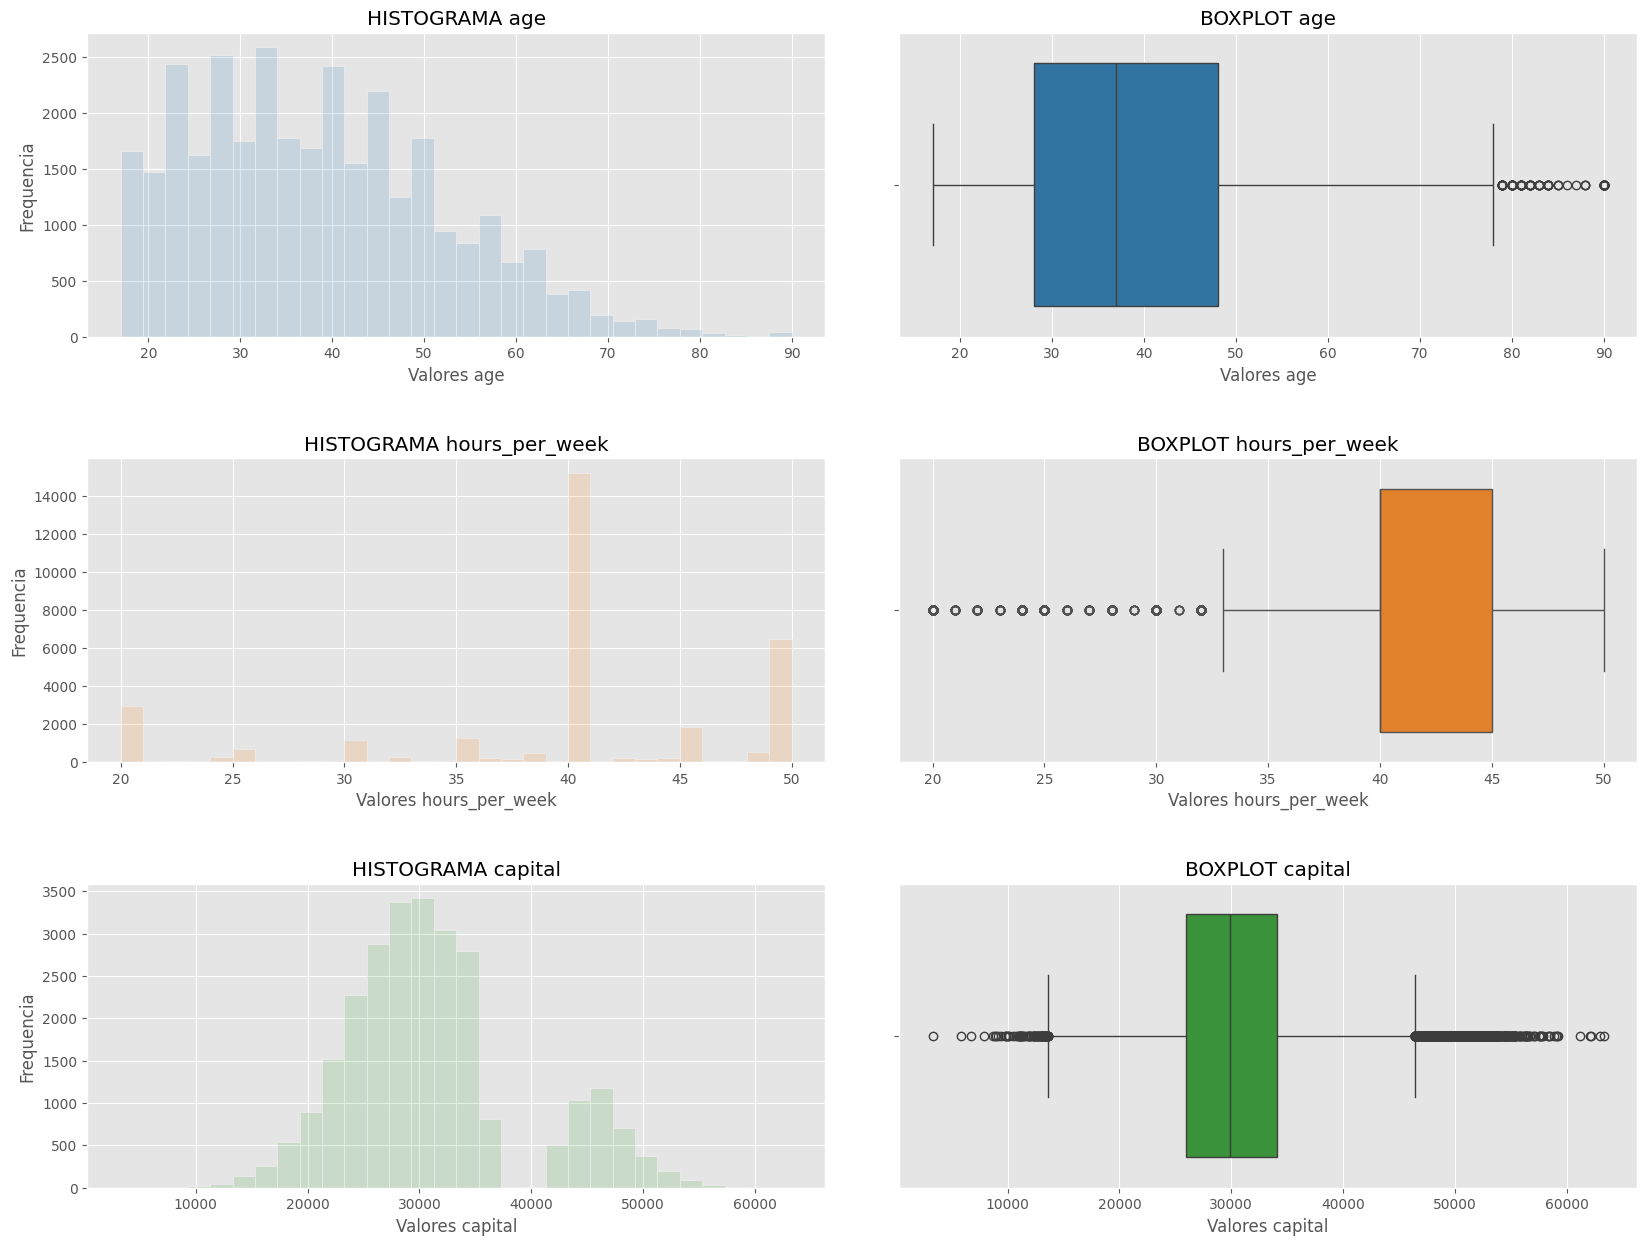

In [49]:
# Eliminar la columna 'ID' de las variables numéricas
var_num_analisis = [col for col in var_num if col != 'ID']

graf_histo_box_numericas(df_adult, var_num_analisis)

* **age**: La distribución de la edad está sesgada hacia la derecha, lo que significa que hay una "cola" más larga en el lado derecho. La mayoría de las edades se concentran en los valores más bajos.
* **hours_per_week**: La distribución de las horas por semana es bastante simétrica, con un pico alrededor de las 40 horas. Tiene una ligera "cola" hacia la derecha, indicando que hay algunas personas que trabajan más horas de lo común.
* **capital**: La distribución de la variable capital está fuertemente sesgada hacia la derecha, con una "cola" muy pronunciada. La mayoría de los valores de capital son bajos, y hay algunos valores muy altos que se extienden hacia la derecha.



b) ¿Presenta outliers? ¿Cómo y donde se distribuyen? (respecto de la caja)

*(Puntuación: 0.5 ptos)*

* **age**: Presenta outliers en el extremo superior, distribuidos por encima del límite superior de la caja.
* **hours_per_week**: Presenta outliers en ambos extremos, por encima y por debajo de la caja, aunque son más numerosos en el extremo superior.
* **capital**: Presenta una gran cantidad de outliers en el extremo superior, distribuidos muy por encima del límite superior de la caja.

## Pregunta 3: Análisis Unidimensional Categórico.

Dibuja las gráficas necesarias (utiliza "countplot" de seaborn)

Interpreta los resultados (con tus palabras):

a) ¿Cómo es la distribución de cada variable categórica (excepto el target)? ¿Cuántos valores únicos tiene? ¿Como es el reparto de individuos (filas) entre ellos? Si ves posibles casos donde se pueda aplicar agrupamiento, señalalo y justificalo. Escribe el código para UN SOLO caso

*(Puntuación: 1.5 ptos)*

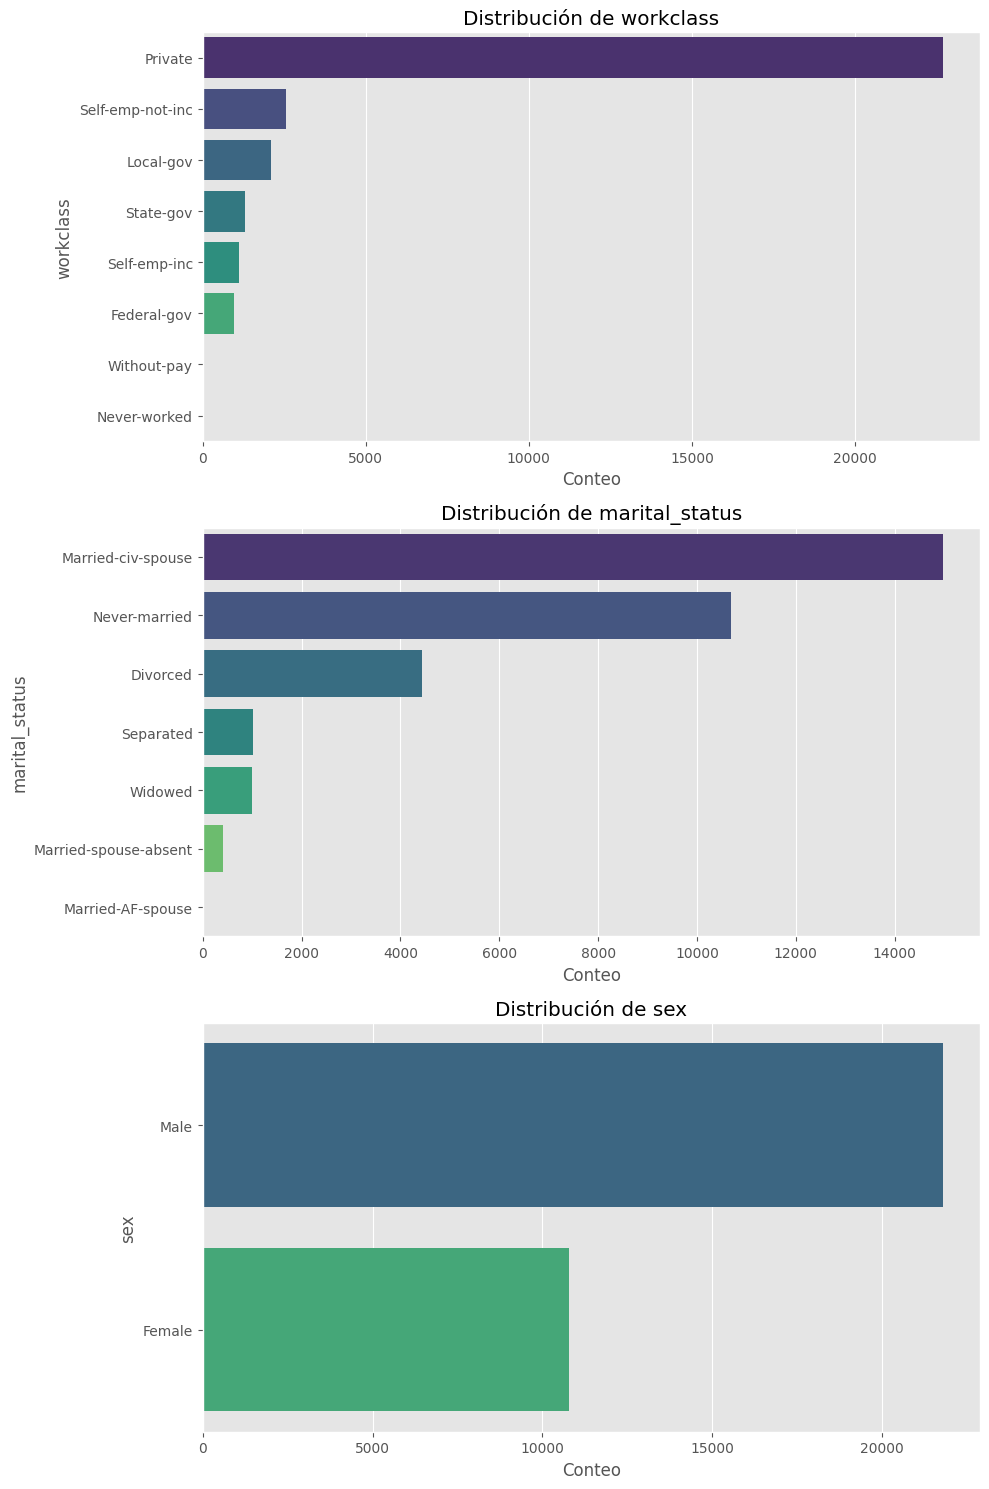

In [50]:
var_cat_analisis = [col for col in var_cat if col != 'income']

fig, axes = plt.subplots(len(var_cat_analisis), 1, figsize=(10, 5 * len(var_cat_analisis)))
axes = axes.ravel()

for idx, cat_col in enumerate(var_cat_analisis):
    sns.countplot(y=cat_col, data=df_adult, ax=axes[idx], order=df_adult[cat_col].value_counts().index, palette='viridis')
    axes[idx].set_title(f'Distribución de {cat_col}')
    axes[idx].set_xlabel('Conteo')
    axes[idx].set_ylabel(cat_col)

plt.tight_layout()
plt.show()

**Distribución de cada variable categórica (excepto el target), número de valores únicos y reparto de individuos:**

* **workclass** (tipo de trabajo): Aquí vemos de dónde saca la gente sus ingresos. La mayoría trabaja para empresas privadas ('Private'). Luego hay grupitos más pequeños que trabajan por su cuenta ('Self-emp-not-inc', 'Self-emp-inc'), para el gobierno ('Local-gov', 'State-gov', 'Federal-gov'), y unos poquitos que no les pagan ('Without-pay') o nunca han trabajado ('Never-worked'). También hay algunos datos que faltan aquí (los NaN). Como hay varios tipos de trabajos de gobierno, a veces se juntan en un solo grupo para simplificar. Lo mismo con los que trabajan por su cuenta.
* **marital_status** (estado civil): Esto nos dice si la gente está casada, soltera, divorciada, etc. La mayoría está casada en plan "tradicional" ('Married-civ-spouse'), seguido por los solteros ('Never-married') y los divorciados ('Divorced'). Los otros estados civiles tienen mucha menos gente. Podríamos juntar todos los tipos de "casado" en un solo grupo si no nos interesa tanto el detalle.
* **sex** (género): Aquí solo hay dos opciones: 'Male' (hombre) y 'Female' (mujer). Vemos que hay más hombres que mujeres en este grupo de datos. Aquí no hay mucho que simplificar, son solo dos categorías.

Ejemplo de agrupamiento (para la variable 'workclass'):

In [51]:
df_adult['workclass_agrupado'] = df_adult['workclass'].replace(['State-gov', 'Local-gov', 'Federal-gov'], 'Government')
print(df_adult['workclass_agrupado'].value_counts())

workclass_agrupado
Private             22696
Government           4351
Self-emp-not-inc     2541
Self-emp-inc         1116
Without-pay            14
Never-worked            7
Name: count, dtype: int64


b) ¿Cómo es la distribución del target "income"? ¿Cuántos valores únicos tiene? ¿Ves muy preocupante la diferencia entre ambas?

*(Puntuación: 0.5 ptos)*

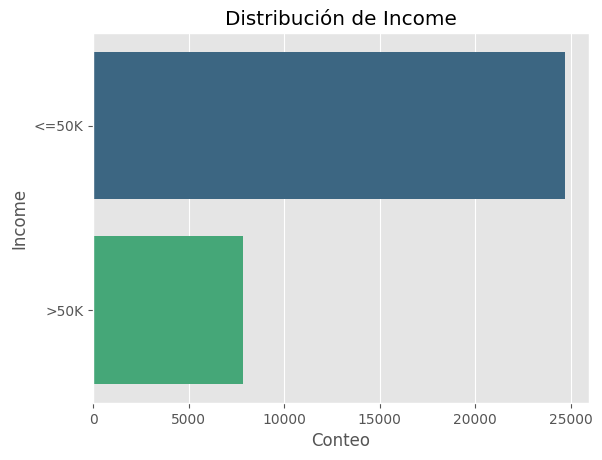

In [52]:
sns.countplot(y='income', data=df_adult, order=df_adult['income'].value_counts().index, palette='viridis')
plt.title('Distribución de Income')
plt.xlabel('Conteo')
plt.ylabel('Income')
plt.show()

b) **Distribución del target "income":**

La variable "income" (ingresos) solo tiene dos opciones: ganar menos o igual a 50K, o ganar más de 50K.

Cuando miras el gráfico, se nota bastante que hay mucha más gente en el grupo de los que ganan menos o igual a 50K que en el grupo de los que ganan más de 50K.

Esto es algo a tener en cuenta si luego quieres usar estos datos para predecir si alguien gana mucho o poco. Si el modelo solo ve un montón de gente en un grupo, podría volverse un poco "vago" y simplemente adivinar que todos ganan menos de 50K, sin esforzarse mucho en encontrar a los que ganan más. Habría que pensar en cómo arreglar eso más adelante para que el modelo sea más justo con ambos grupos.

## Pregunta 4: Análisis Bidimensional / Multidimensional.

Dibuja las gráficas necesarias. Interpreta los resultados (con tus palabras):

a) NUMÉRICO-NUMÉRICO. Utilizando las gráficas correspondientes, ¿qué puedes decir de los valores arrojados? ¿Hay variables que estén correladas entre sí? ¿Si es así, que harías?

*(Puntuación: 1.5 ptos)*

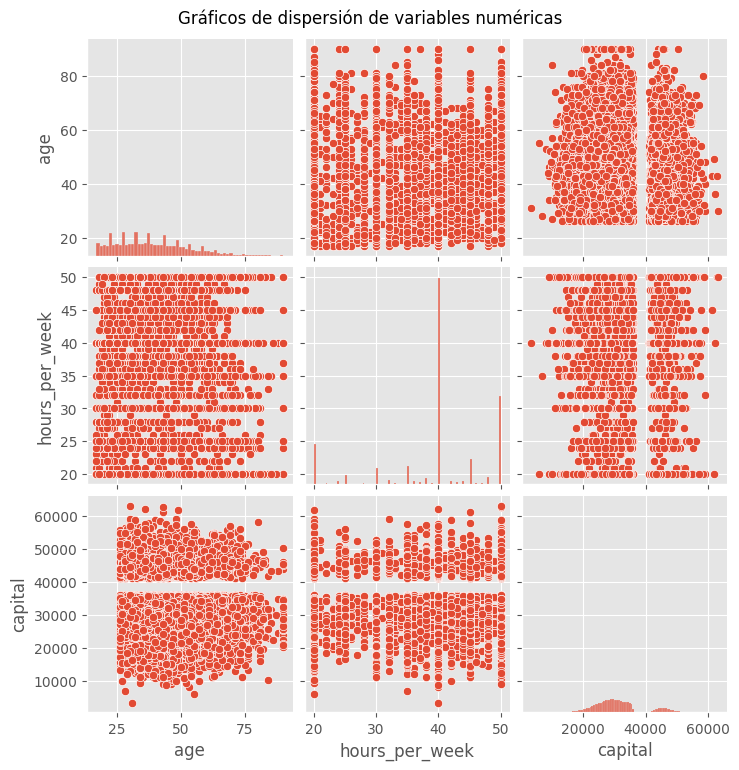

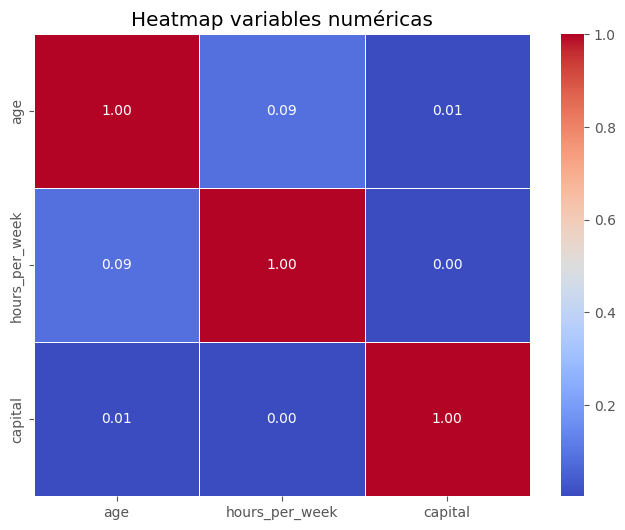

In [53]:
# Excluir ID
df_num = df_adult[var_num_analisis]

# Crear un gráfico de dispersión
sns.pairplot(df_num)
plt.suptitle('Gráficos de dispersión de variables numéricas', y=1.02)
plt.show()

# Calcular la matriz de correlación
corr_matrix = df_num.corr()

# Dibujar un mapa de calor de la matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap variables numéricas')
plt.show()

Al mirar cómo se relacionan la edad, las horas que trabajan por semana y el capital (ahorros) de las personas en este grupo, nos damos cuenta de algo:

* No hay una conexión muy fuerte o clara entre ninguna de estas tres cosas.

* Que seas mayor no significa que trabajes muchísimas más horas a la semana, ni que tengas un capital mucho mayor de forma directa y predecible. Hay una pequeña tendencia a que el capital suba un poquito con la edad, pero es una relación muy floja.
* Tampoco parece que trabajar más horas a la semana te asegure tener mucho más capital, o al revés.

En resumen: estas tres variables numéricas van un poco "por su lado", no están fuertemente ligadas entre sí en este conjunto de datos.

Si encontráramos variables numéricas que estuvieran muy, muy conectadas entre sí (con una correlación alta), podríamos hacer un par de cosas:

* Eliminar una de ellas: Como ya tienen información muy parecida, a veces con quedarnos con una sola es suficiente para el análisis o el modelo.
* Combinarlas: Podríamos intentar juntar la información de las variables correlacionadas en una sola variable nueva.

b) NUMÉRICO-CATEGÓRICO. Estudia la relación entre la variable "edad" y el target "income"
¿Sacas alguna conclusión? Razonalo

*(Puntuación: 1 ptos)*

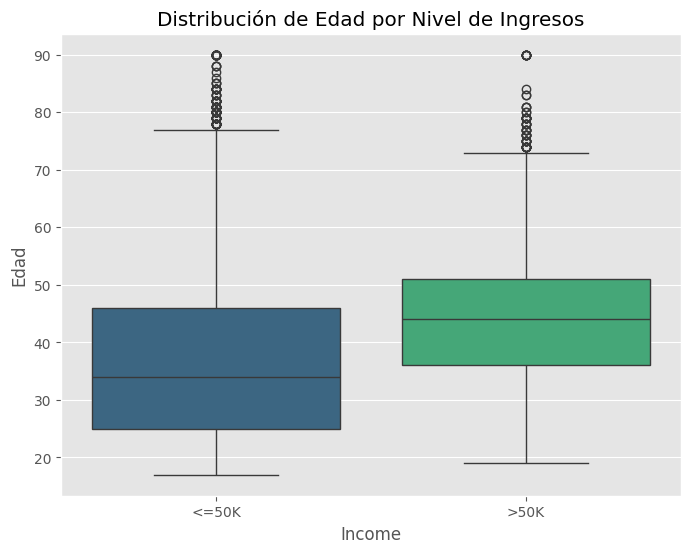

In [54]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='income', y='age', data=df_adult, palette='viridis')
plt.title('Distribución de Edad por Nivel de Ingresos')
plt.xlabel('Income')
plt.ylabel('Edad')
plt.show()

**Relación entre Edad e Income:**

Al mirar el gráfico que muestra la edad de la gente según si ganan más o menos de 50K, podemos notar algo interesante:

*   En general, parece que la gente que gana **más de 50K** tiende a ser **un poco mayor** que la gente que gana menos o igual a 50K.
*   La "caja" (que representa a la mayoría de la gente en cada grupo) del grupo que gana más de 50K está un poco más arriba en el eje de la edad que la caja del grupo que gana menos. Esto significa que la edad promedio y típica es mayor para los que ganan más.
*   Hay personas de todas las edades en ambos grupos, pero la concentración de edades es diferente.

Sí, parece que hay una relación: **la gente con mayores ingresos tiende a ser, en promedio, mayor que la gente con menores ingresos** en este conjunto de datos. Esto tiene sentido, ya que ganar más dinero a menudo requiere más experiencia laboral, que se gana con el tiempo.

## Pregunta 5: Estudio nulos con missingno.

Dibuja las gráficas necesarias utilizando la libreria missingno. Interpreta los resultados (con tus palabras):

a) ¿Con cuál de los métodos de dibujado de "missingno" podrías distinguir las FILAS con nulos en nuestros datos? ¿Que significa en el lado derecho de la gráfica los números que están junto al trazado?

*(Puntuación: 1 ptos)*

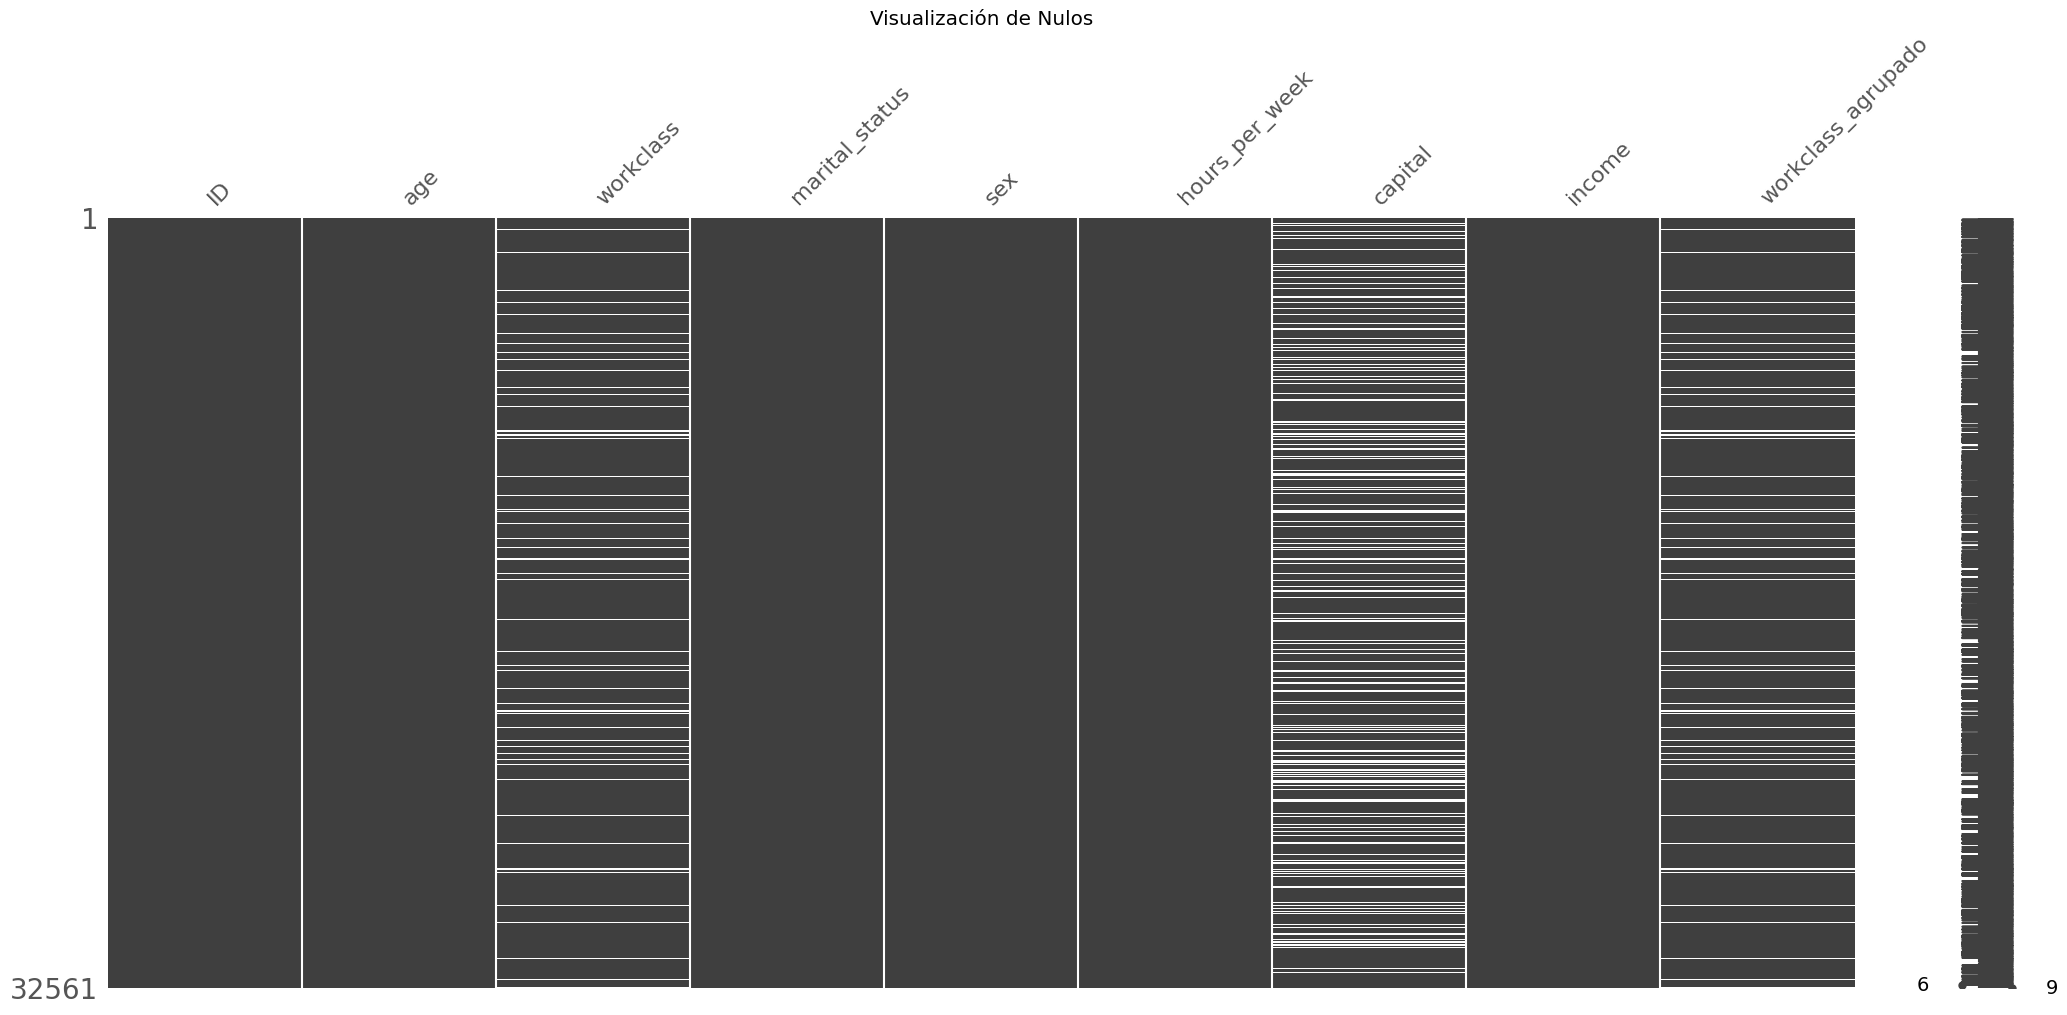

In [55]:
msno.matrix(df_adult)
plt.title('Visualización de Nulos')
plt.show()

En el lado derecho de la gráfica, los números junto al trazado representan el número de valores no nulos en cada fila. Por ejemplo, si ves un "8" al lado de una fila, significa que esa fila tiene 8 valores no nulos en total (contando todas las columnas). Si una fila tiene menos de 8, es que le faltan datos en alguna de las columnas.

b) ¿Qué metodo de dibujado de "missingno" habría que utilizar para ver el PORCENTAJE de NULOS en cada COLUMNA? Utilizala en nuestra gráfica e indica la columna con mayor y la columna con menor porcentaje de nulos

*(Puntuación: 1 ptos)*

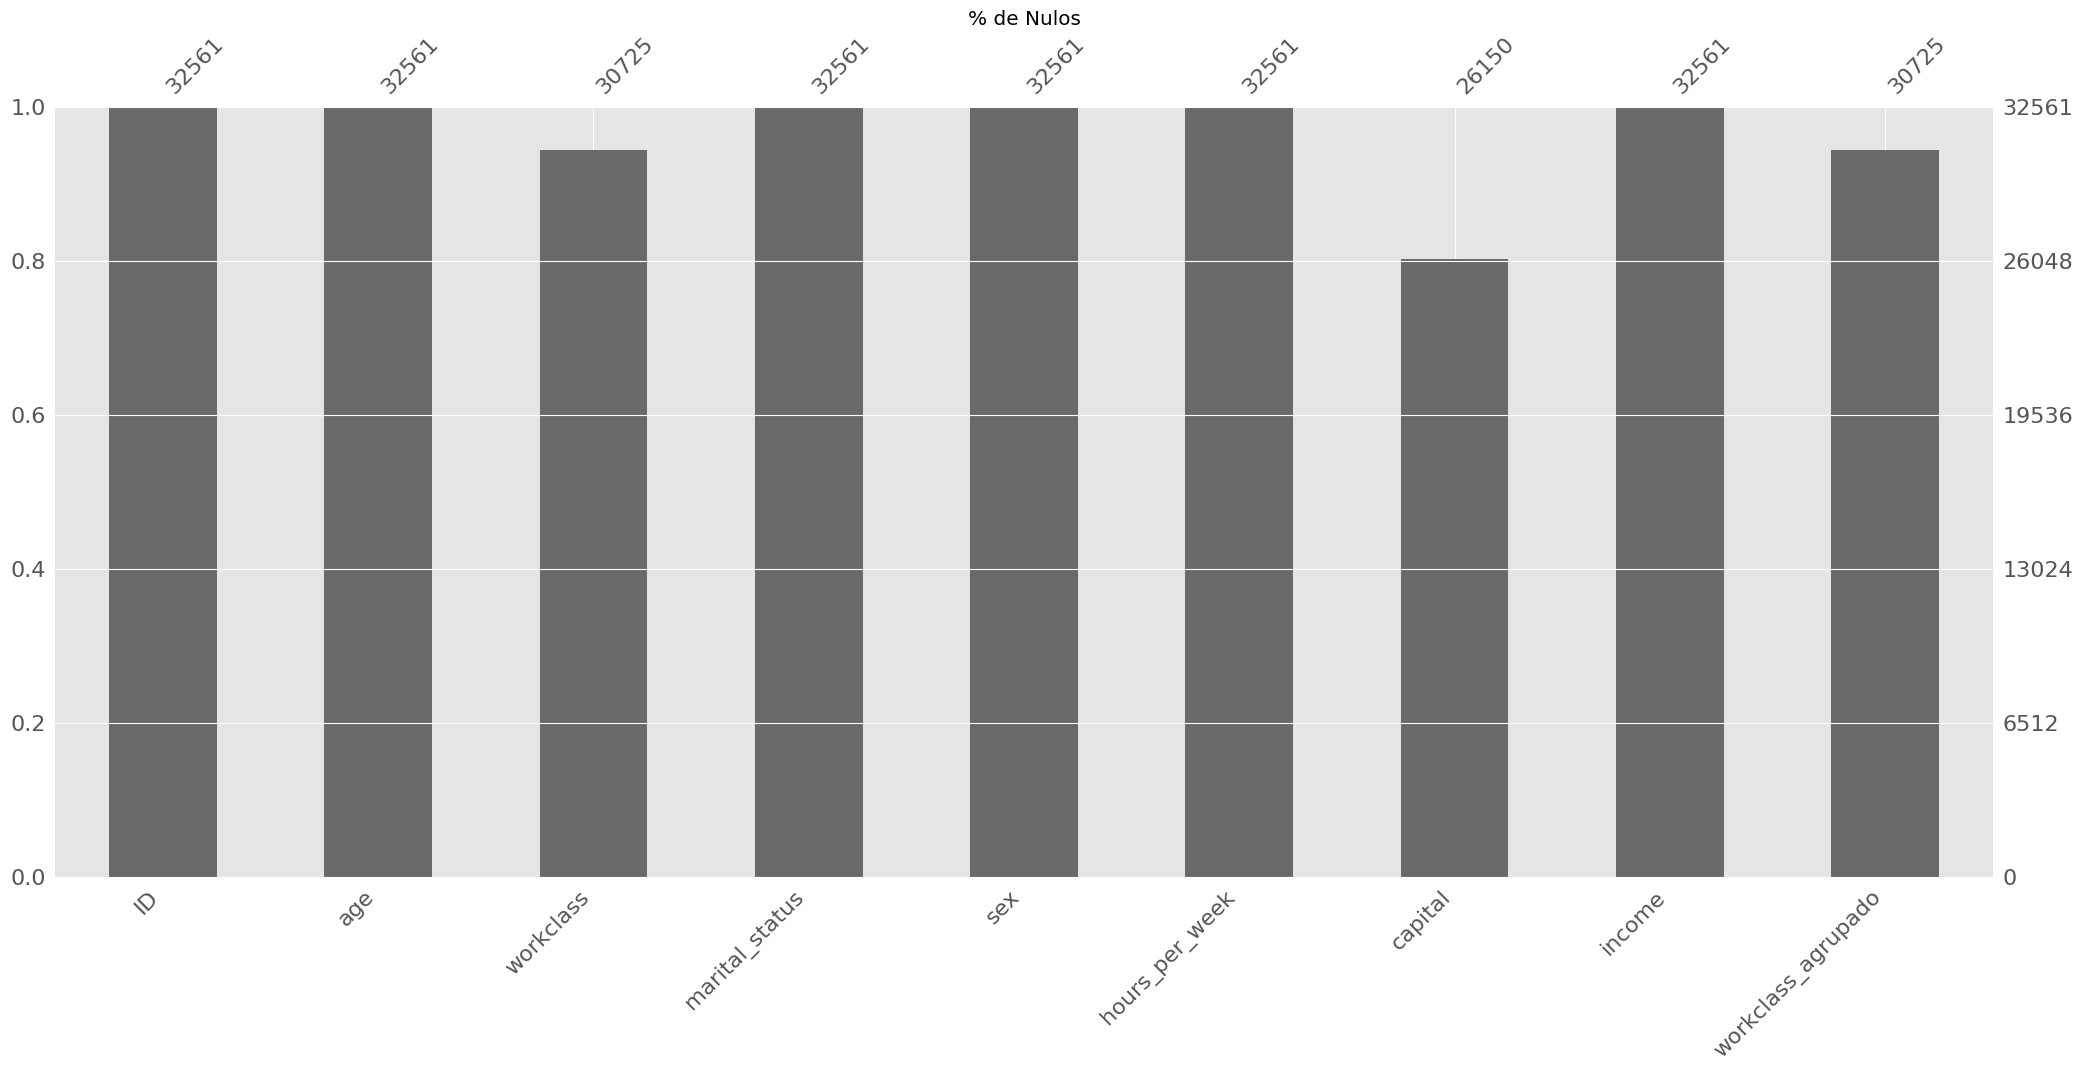

In [56]:
msno.bar(df_adult);
plt.title('% de Nulos')
plt.show()

* La columna con el mayor porcentaje de nulos es 'capital'.
* La columna con el menor porcentaje de nulos es 'ID', 'age', 'marital_status', 'sex', 'hours_per_week', 'income' (todas estas columnas no tienen valores nulos, por lo tanto, tienen el 0% de nulos).

## Pregunta 6: Outliers.

Fijandonos SOLO en los outliers de "edad" y "horas de trabajo semanales":

a) Calcula el nº de outliers que hay en cada. Puedes ayudarte con las funciones que están al comienzo del notebook.

*(Puntuación: 0.75 ptos)*

In [57]:
# Calcular límites para 'age'
lim_inferior_age, lim_superior_age = calculos_boxplot(df_adult['age'])

# Contar outliers en 'age'
outliers_age = df_adult[(df_adult['age'] < lim_inferior_age) | (df_adult['age'] > lim_superior_age)]
num_outliers_age = len(outliers_age)

print(f'\nNúmero de outliers en "age": {num_outliers_age}')
print('\n')
# Calcular límites para 'hours_per_week'
lim_inferior_hours, lim_superior_hours = calculos_boxplot(df_adult['hours_per_week'])

# Contar outliers en 'hours_per_week'
outliers_hours = df_adult[(df_adult['hours_per_week'] < lim_inferior_hours) | (df_adult['hours_per_week'] > lim_superior_hours)]
num_outliers_hours = len(outliers_hours)

print(f'\nNúmero de outliers en "hours_per_week": {num_outliers_hours}')


Cuartiles:  28.0 	 48.0
IQR:  20.0
Limite inferior:  -2.0
Limite superior:  78.0

Número de outliers en "age": 143


Cuartiles:  40.0 	 45.0
IQR:  5.0
Limite inferior:  32.5
Limite superior:  52.5

Número de outliers en "hours_per_week": 5516


b) ¿Que harías con cada uno, teniendo en cuenta también su número, cuál eliminarías y cual recortarías? Justificalo.

*(Puntuación: 0.50 ptos)*

* **Outliers en "age" (edad)**: Hay una cantidad relativamente pequeña (143). Como no son tantos, podríamos considerar eliminarlos. Perderíamos solo un pequeño porcentaje del total de datos.
* **Outliers en "hours_per_week" (horas de trabajo semanales)**: Aquí hay un número bastante grande de outliers (5516). Si los eliminamos todos, perderíamos muchísimas filas del dataset, lo cual no es ideal. Por eso, para esta variable, sería mejor recortar los outliers. Esto significa que, en lugar de eliminar las filas con valores extremos, a esos valores les asignamos el límite superior o inferior calculado. Así mantenemos las filas pero "suavizamos" los valores extremos.

La justificación es simple: no queremos perder demasiados datos eliminando un gran número de filas por outliers.

c) Teniendo en cuenta lo que contestaste en el apartado anterior, corrige SOLO UNO DE ELLOS, EL QUE PREFIERAS.

*(Puntuación: 0.75 ptos)*


Número de outliers en 'hours_per_week' después del recortado:
0


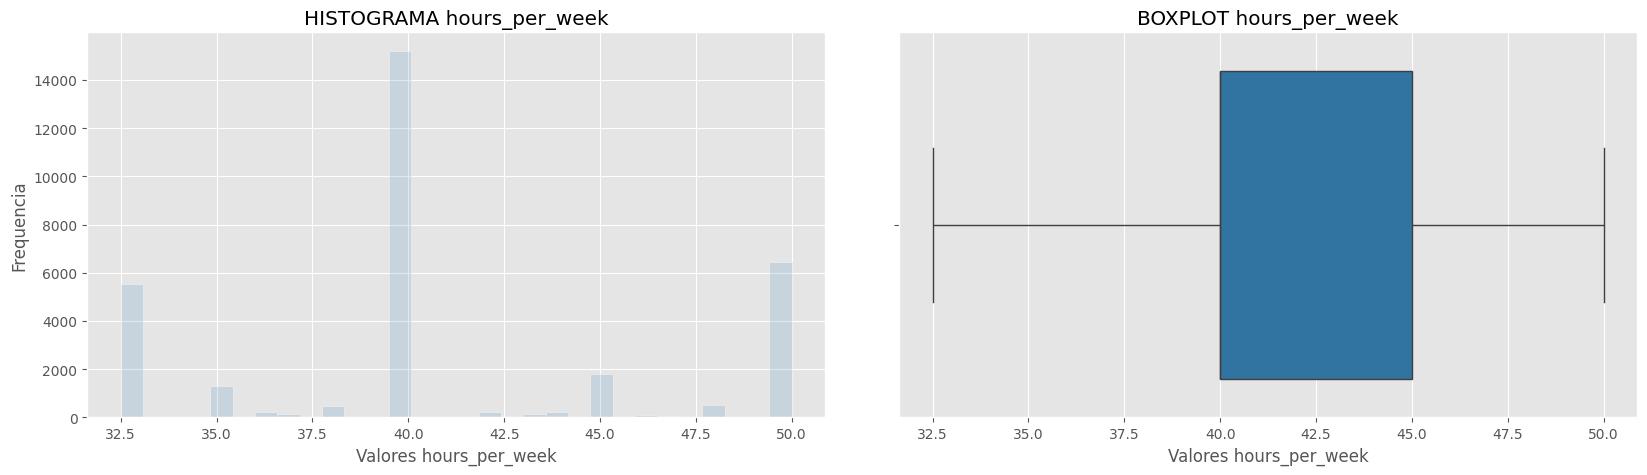

In [58]:
# Usamos los límites calculados anteriormente: lim_inferior_hours, lim_superior_hours
df_adult['hours_per_week'] = np.where(df_adult['hours_per_week'] < lim_inferior_hours, lim_inferior_hours, df_adult['hours_per_week'])
df_adult['hours_per_week'] = np.where(df_adult['hours_per_week'] > lim_superior_hours, lim_superior_hours, df_adult['hours_per_week'])

# Verificar si se aplicó el recortado (mostrando el boxplot de nuevo y recalculando los outliers)
graf_histo_box_numericas(df_adult, ['hours_per_week'])
print("\nNúmero de outliers en 'hours_per_week' después del recortado:")
outliers_hours_after = df_adult[(df_adult['hours_per_week'] < lim_inferior_hours) | (df_adult['hours_per_week'] > lim_superior_hours)]
print(len(outliers_hours_after))